# FTIR EC calibration — step-by-step optimization

**Goal.** Show *exactly* how the EC calibration data is processed, and actually **optimize** it by
removing the odd values (outliers) the way Mona does in the tool — something our "faithful replica"
(which reproduced the un-cleaned K=31 export) did **not** yet do.

**Data.** We use the tool's **exact** training set, extracted from its exported model object
(`pls-EC-2026-06-24.RDS`): 906 IMPROVE biomass-burning spectra (lot 251), 2722 wavenumbers, and the
tool's exact measured EC (`MatchedValue`). We proved earlier that `sklearn.PLSRegression(scale=False)`
reproduces the tool's R `kernelpls` to ~1e-10 on this data, so everything here is an exact stand-in
for the tool — no server needed.

**Mona's outlier rules (from the training call):**
1. Remove **measured-negative** samples outright ("mass should never be measured negative").
2. Remove **gross residual outliers** iteratively: fit, drop the points far off the 1:1 line, refit —
   thresholds scaled to the residual spread (her "remove >400, then >300, then >200" when residuals
   are that large; here loadings are ~10 µg so we scale to the data).
3. Remove **flagged-questionable / broken / over-loaded** filters — *requires a flag column we don't
   have in this export*, so we note where it would go but can't reproduce it here.
4. Pick the **number of PLS components** at the minimum cross-validated RMSEP.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, cross_val_predict

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "research").exists() and (cand / "AGENTS.md").exists():
            return cand
    return Path.cwd()

ROOT = find_repo_root()
HERE = ROOT / "research/spartan_ec_2026_06_16"
DATA = HERE / "data"
print("data dir:", DATA)

data dir: /Users/ahmadjalil/github/aethmodular/research/spartan_ec_2026_06_16/data


## 1. Load the tool's exact training data
X = spectra (906 × 2722), y = measured EC loading (µg), plus per-filter metadata (Site, date).

In [2]:
X = pd.read_csv(DATA / "rds_EC_X.csv").drop(columns=["id"])
y = pd.read_csv(DATA / "rds_EC_Ymeasured.csv")["Y_measured"].to_numpy(float)
wv = pd.read_csv(DATA / "rds_EC_coef_k18.csv")["wavenumber"].to_numpy(float)  # column order
meta = pd.read_csv(DATA / "rds_EC_metadata.csv")
X.columns = [f"{w:.4f}" for w in wv]
print("X:", X.shape, "| y:", y.shape, "| wavenumbers:", wv.min(), "-", wv.max(), "cm^-1")
print("\nmeasured EC loading (µg) summary:")
print(pd.Series(y).describe().round(2).to_string())
print("\nmeasured negatives:", int((y < 0).sum()))

X: (906, 2722) | y: (906,) | wavenumbers: 500.124317346017 - 3998.42320552162 cm^-1

measured EC loading (µg) summary:
count    906.00
mean      16.88
std       25.89
min        0.77
25%        7.50
50%       10.70
75%       17.64
max      393.33

measured negatives: 0


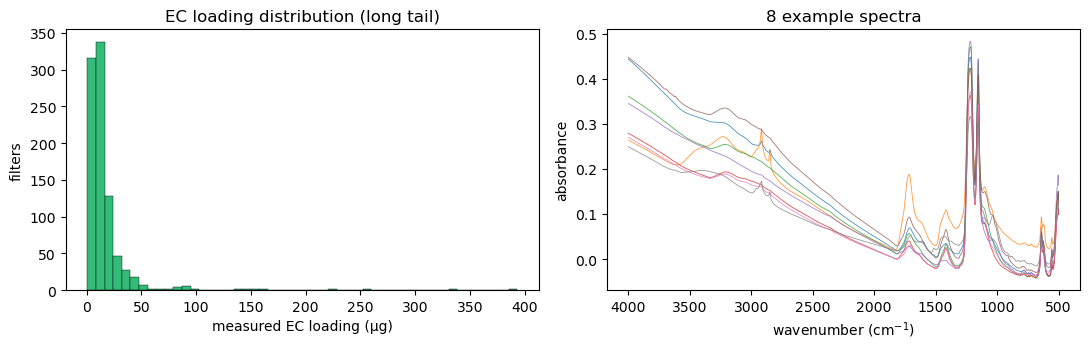

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(y, bins=50, color="#3b7", edgecolor="k", lw=0.3)
ax[0].set(xlabel="measured EC loading (µg)", ylabel="filters", title="EC loading distribution (long tail)")
ax[1].plot(wv, X.iloc[:8].T, lw=0.6, alpha=0.8)
ax[1].set(xlabel="wavenumber (cm$^{-1}$)", ylabel="absorbance", title="8 example spectra")
ax[1].invert_xaxis()
plt.tight_layout(); plt.show()

## 2. Baseline fit (no cleaning) — the current un-optimized state
We sweep the PLS component count, pick the minimum cross-validated RMSEP, and look at the
measured-vs-predicted fit. This is essentially what the exported K=31 calibration is: **no outliers
removed.**

In [4]:
def rmsep_curve(Xv, yv, ks, cv=5, seed=0):
    kf = KFold(n_splits=cv, shuffle=True, random_state=seed)
    out = {}
    for k in ks:
        if k >= min(Xv.shape): continue
        pred = cross_val_predict(PLSRegression(n_components=k, scale=False), Xv, yv, cv=kf)
        out[k] = float(np.sqrt(np.mean((yv - pred.ravel())**2)))
    return out

def raw_coef(model, p):
    ic = float(np.asarray(model.predict(np.zeros((1, p)))).reshape(-1)[0])
    return np.asarray(model.predict(np.eye(p))).reshape(-1) - ic, ic

def fit_stats(Xv, yv, k):
    m = PLSRegression(n_components=k, scale=False).fit(Xv, yv)
    pred = m.predict(Xv).ravel()
    r2 = 1 - np.sum((yv-pred)**2)/np.sum((yv-yv.mean())**2)
    rmse = float(np.sqrt(np.mean((yv-pred)**2)))
    bias = 100*np.mean(pred-yv)/np.mean(yv)
    return m, pred, dict(r2=r2, rmse=rmse, bias=bias)

KS = range(5, 41, 2)
Xa = X.to_numpy(float)
curve0 = rmsep_curve(Xa, y, KS)
k0 = min(curve0, key=curve0.get)
m0, pred0, s0 = fit_stats(Xa, y, k0)
print(f"baseline: best K={k0}  CV-RMSEP={curve0[k0]:.2f}  in-sample R2={s0['r2']:.3f} RMSE={s0['rmse']:.2f} bias={s0['bias']:+.1f}%")

baseline: best K=21  CV-RMSEP=16.63  in-sample R2=0.840 RMSE=10.35 bias=+0.0%


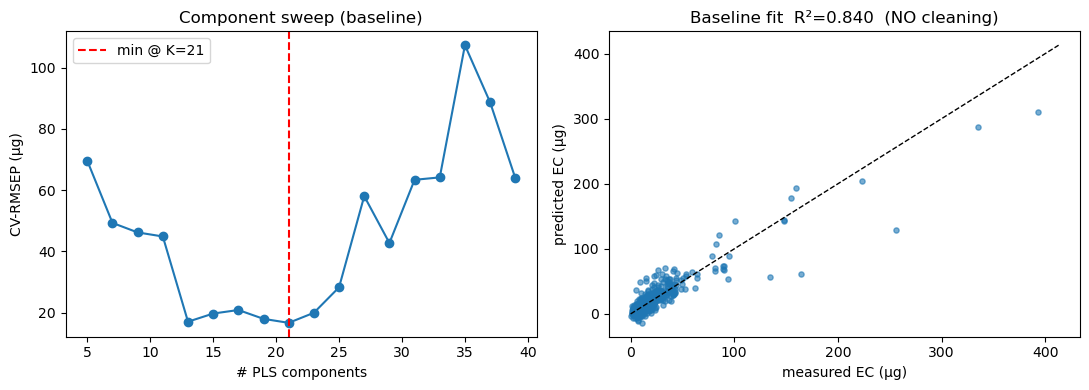

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(curve0), list(curve0.values()), "o-")
ax[0].axvline(k0, color="r", ls="--", label=f"min @ K={k0}")
ax[0].set(xlabel="# PLS components", ylabel="CV-RMSEP (µg)", title="Component sweep (baseline)"); ax[0].legend()
ax[1].scatter(y, pred0, s=14, alpha=0.6)
lim = max(y.max(), pred0.max())*1.05
ax[1].plot([0, lim], [0, lim], "k--", lw=1)
ax[1].set(xlabel="measured EC (µg)", ylabel="predicted EC (µg)",
          title=f"Baseline fit  R²={s0['r2']:.3f}  (NO cleaning)")
plt.tight_layout(); plt.show()

## 3. Identify the odd values
Compute residuals (measured − predicted). The points far off the 1:1 line are the candidates Mona
removes. We tag them by Site and date so it's clear *which* filters they are.

In [6]:
resid0 = y - pred0
od = meta.copy()
od["measured"] = y; od["predicted"] = pred0; od["residual"] = resid0; od["abs_resid"] = np.abs(resid0)
print("residual spread: std =", round(resid0.std(), 2), "µg | max |resid| =", round(np.abs(resid0).max(), 2))
print("\nTop 12 odd values (largest |residual|):")
print(od.sort_values("abs_resid", ascending=False)
        .head(12)[["Site","SampleDate","measured","predicted","residual"]].round(1).to_string(index=False))

residual spread: std = 10.35 µg | max |resid| = 126.41

Top 12 odd values (largest |residual|):
 Site SampleDate  measured  predicted  residual
WICA1 2022-10-17     256.0      129.6     126.4
YOSE1 2022-07-10     164.7       60.9     103.8
TOOL1 2022-07-01     393.3      310.9      82.5
WHPA1 2022-09-11     134.7       56.3      78.4
HECA1 2022-09-05     335.3      287.5      47.7
CABI1 2022-09-11     100.7      142.2     -41.5
PUSO1 2022-10-20      93.9       53.2      40.7
SULA1 2022-10-17      26.5       66.9     -40.4
BIRM1 2022-07-04       9.0       48.9     -39.9
BRID1 2022-11-13      15.2       54.5     -39.2
DENA1 2022-07-04      33.5       70.0     -36.5
ATLA1 2022-07-04      15.0       50.8     -35.8


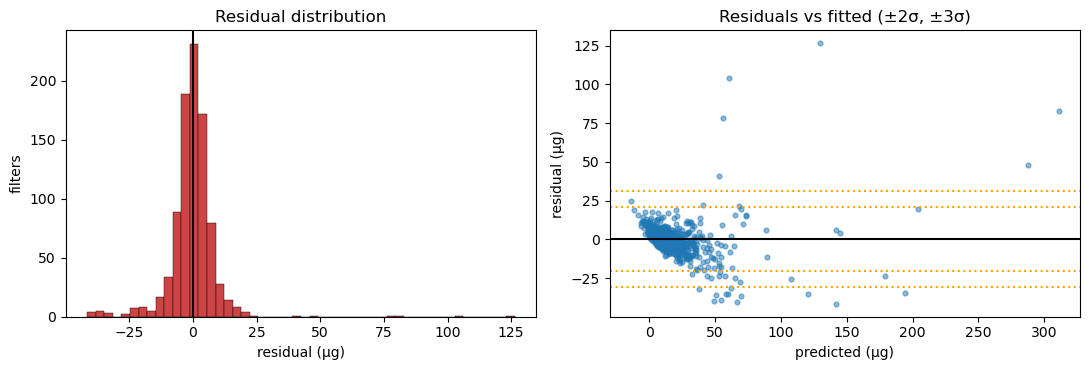

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(resid0, bins=50, color="#c44", edgecolor="k", lw=0.3)
ax[0].axvline(0, color="k"); ax[0].set(xlabel="residual (µg)", ylabel="filters", title="Residual distribution")
ax[1].scatter(pred0, resid0, s=12, alpha=0.5)
for s in (2,3):
    ax[1].axhline(s*resid0.std(), color="orange", ls=":"); ax[1].axhline(-s*resid0.std(), color="orange", ls=":")
ax[1].axhline(0, color="k"); ax[1].set(xlabel="predicted (µg)", ylabel="residual (µg)", title="Residuals vs fitted (±2σ, ±3σ)")
plt.tight_layout(); plt.show()

## 4. Remove outliers iteratively — Mona's loop, made explicit
Each round: (a) drop measured-negatives, (b) fit at the current best K, (c) drop points with
|residual| > 3σ, (d) refit. Repeat until a round removes nothing. We print exactly which filters
leave each round and how R²/RMSE respond — this is the transparency you asked for.

In [8]:
keep = np.ones(len(y), dtype=bool)
# (a) measured negatives (none expected here, but this is the rule)
neg = y < 0
print(f"round 0: drop {int(neg.sum())} measured-negative filters")
keep &= ~neg

SIGMA = 3.0
removed_log = []
# trim at the baseline component count (cheap single fits); we re-pick K once at the end.
for rnd in range(1, 6):
    Xk, yk = Xa[keep], y[keep]
    m, pred, st = fit_stats(Xk, yk, k0)
    res = yk - pred
    thr = SIGMA * res.std()
    drop_local = np.abs(res) > thr
    n_drop = int(drop_local.sum())
    print(f"round {rnd}: n={keep.sum()}  K={k0}  R²={st['r2']:.3f}  RMSE={st['rmse']:.2f}  "
          f"3σ threshold={thr:.1f}µg  -> drop {n_drop}")
    if n_drop == 0:
        break
    idx_global = np.where(keep)[0][drop_local]
    for gi in idx_global:
        removed_log.append({"round": rnd, "Site": meta.iloc[gi]["Site"],
                            "SampleDate": meta.iloc[gi]["SampleDate"],
                            "measured": round(float(y[gi]), 1)})
    keep[idx_global] = False

print(f"\nTotal removed: {int((~keep).sum())} of {len(y)}  ({100*(~keep).mean():.1f}%)")
print(pd.DataFrame(removed_log).to_string(index=False))

round 0: drop 0 measured-negative filters


round 1: n=906  K=21  R²=0.840  RMSE=10.35  3σ threshold=31.0µg  -> drop 18


round 2: n=888  K=21  R²=0.926  RMSE=4.38  3σ threshold=13.1µg  -> drop 14


round 3: n=874  K=21  R²=0.930  RMSE=3.24  3σ threshold=9.7µg  -> drop 14
round 4: n=860  K=21  R²=0.943  RMSE=2.80  3σ threshold=8.4µg  -> drop 4


round 5: n=856  K=21  R²=0.943  RMSE=2.71  3σ threshold=8.1µg  -> drop 2

Total removed: 52 of 906  (5.7%)
 round  Site SampleDate  measured
     1 UPBU1 2023-03-19      22.9
     1 DENA1 2022-07-04      33.5
     1 CHAS1 2023-01-30      30.4
     1 CABI1 2022-09-11     100.7
     1 HECA1 2022-09-05     335.3
     1 LTCC1 2022-09-11     159.9
     1 SULA1 2022-10-17      26.5
     1 KPBO1 2022-06-28      24.2
     1 BIRM1 2022-07-04       9.0
     1 YOSE1 2022-07-10     164.7
     1 WICA1 2022-10-17     256.0
     1 ATLA1 2022-07-04      15.0
     1 BRID1 2022-11-10       5.6
     1 WHPA1 2022-09-11     134.7
     1 TOOL1 2022-07-01     393.3
     1 BRID1 2022-11-13      15.2
     1 BIRM1 2023-04-12      85.0
     1 PUSO1 2022-10-20      93.9
     2 DENA1 2022-06-28      94.8
     2 JARI1 2022-07-04       9.8
     2 COHU1 2023-02-08      42.7
     2 BLIS2 2022-09-08     155.2
     2 HECA1 2022-09-11      34.2
     2 YOSE1 2022-09-02      88.9
     2 YOSE1 2022-09-05      89.8
     2 YO

## 5. Re-optimize the component count on the cleaned data, and fit the final calibration

In [9]:
Xc, yc = Xa[keep], y[keep]
curveF = rmsep_curve(Xc, yc, KS)
kF = min(curveF, key=curveF.get)
mF, predF, sF = fit_stats(Xc, yc, kF)
coefF, icF = raw_coef(mF, Xc.shape[1])
print(f"OPTIMIZED: n={keep.sum()}  K={kF}  CV-RMSEP={curveF[kF]:.2f}  "
      f"R²={sF['r2']:.3f}  RMSE={sF['rmse']:.2f}  bias={sF['bias']:+.1f}%")
print(f"(baseline was: n={len(y)}  K={k0}  R²={s0['r2']:.3f}  RMSE={s0['rmse']:.2f})")

OPTIMIZED: n=854  K=39  CV-RMSEP=12.41  R²=0.964  RMSE=2.15  bias=+0.0%
(baseline was: n=906  K=21  R²=0.840  RMSE=10.35)


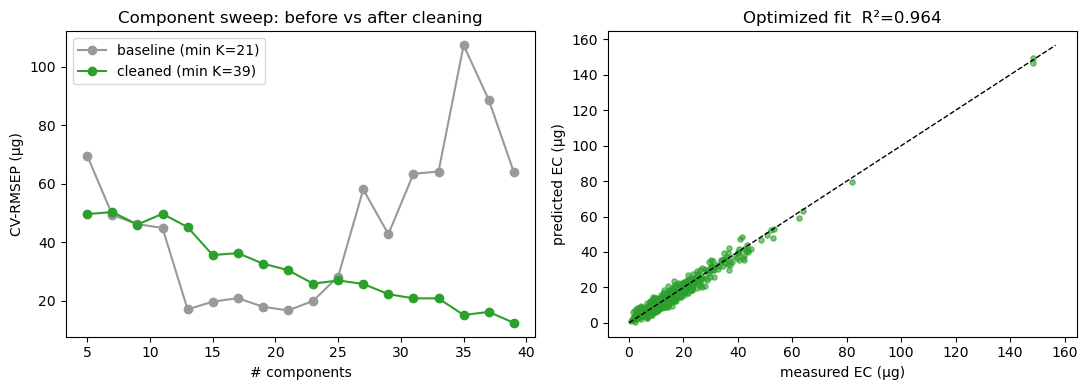

wrote data/calib_EC_biomass_lot251_OPTIMIZED.csv


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(curve0), list(curve0.values()), "o-", color="0.6", label=f"baseline (min K={k0})")
ax[0].plot(list(curveF), list(curveF.values()), "o-", color="C2", label=f"cleaned (min K={kF})")
ax[0].legend(); ax[0].set(xlabel="# components", ylabel="CV-RMSEP (µg)", title="Component sweep: before vs after cleaning")
ax[1].scatter(yc, predF, s=14, alpha=0.6, color="C2")
lim = max(yc.max(), predF.max())*1.05; ax[1].plot([0,lim],[0,lim],"k--",lw=1)
ax[1].set(xlabel="measured EC (µg)", ylabel="predicted EC (µg)", title=f"Optimized fit  R²={sF['r2']:.3f}")
plt.tight_layout(); plt.show()

# export the optimized coefficients in the tool's shape (wavenumber, b + intercept row)
out = pd.DataFrame({"Wavenumber": wv, "b": coefF})
out = pd.concat([pd.DataFrame({"Wavenumber": [0.0], "b": [icF]}), out], ignore_index=True)
out.to_csv(DATA / "calib_EC_biomass_lot251_OPTIMIZED.csv", index=False)
print("wrote data/calib_EC_biomass_lot251_OPTIMIZED.csv")

## 6. Apply to the 5 Adama filters — general vs baseline-biomass vs optimized-biomass
Sanity: does cleaning the calibration change the Adama EC, and how does it sit against the
independent quartz TOR reference?

In [11]:
import re
WN = re.compile(r"^[+-]?\d+(\.\d+)?$")
sp = pd.read_csv(DATA / "adama/adama_ptfe_spectra_batch54.csv")
awn = [c for c in sp.columns if WN.match(str(c).strip())]
av = np.array([float(c) for c in awn]); o = np.argsort(av); avs = av[o]; ac = [awn[i] for i in o]
def apply_vec(coef, ic, tol=0.3):
    idx = np.clip(np.searchsorted(avs, wv), 1, len(avs)-1)
    pk = np.where(np.abs(wv-avs[idx-1]) <= np.abs(wv-avs[idx]), idx-1, idx)
    ok = np.abs(wv-avs[pk]) <= tol
    return sp[[ac[i] for i in pk[ok]]].to_numpy(float) @ coef[ok] + ic
def apply_csv(path, tol=0.3):
    c = pd.read_csv(path); ic = float(c.loc[c.Wavenumber==0,"b"].iloc[0]); co = c.loc[c.Wavenumber!=0]
    cw = co.Wavenumber.to_numpy(float); cb = co.b.to_numpy(float)
    idx = np.clip(np.searchsorted(avs, cw), 1, len(avs)-1)
    pk = np.where(np.abs(cw-avs[idx-1]) <= np.abs(cw-avs[idx]), idx-1, idx)
    ok = np.abs(cw-avs[pk]) <= tol
    return sp[[ac[i] for i in pk[ok]]].to_numpy(float) @ cb[ok] + ic

coef0, ic0 = raw_coef(m0, Xa.shape[1])
ft = pd.read_csv(DATA / "adama/adama_ptfe_ftir_batch54.csv")
pt = ft[ft.Parameter=="EC_ftir"][["FilterId","SampleDate"]].reset_index(drop=True)
pt["date"] = pd.to_datetime(pt.SampleDate).dt.normalize()
pt["EC_general"] = apply_csv(DATA / "adama/cal_lot241a_245_EC.csv")
pt["EC_biomass_baseline"] = apply_vec(coef0, ic0)
pt["EC_biomass_optimized"] = apply_vec(coefF, icF)
t = pd.read_csv(DATA / "adama/adama_quartz_tor_batch54.csv")
tw = t.pivot_table(index=["FilterId","SampleDate"], columns="Parameter", values="MassLoading_ug").reset_index()
tw["date"] = pd.to_datetime(tw.SampleDate).dt.normalize(); tw["char_soot"] = (tw.EC1-tw.OPTR)/(tw.EC2+tw.EC3)
cmp = pt.merge(tw[["date","ECTR","char_soot"]], on="date", how="left")
print(cmp[["FilterId","EC_general","EC_biomass_baseline","EC_biomass_optimized","ECTR","char_soot"]].round(2).to_string(index=False))

FilterId  EC_general  EC_biomass_baseline  EC_biomass_optimized  ECTR  char_soot
   J1233        3.73                16.31                 13.48  4.81       0.02
   J1266        4.41                17.83                 12.19  6.25       0.07
   J1269       15.19                23.38                 13.35  8.85       0.17
   J1270        2.05                11.69                 11.27  7.75       0.58
   J1285        5.74                19.45                 14.59  6.33       0.07


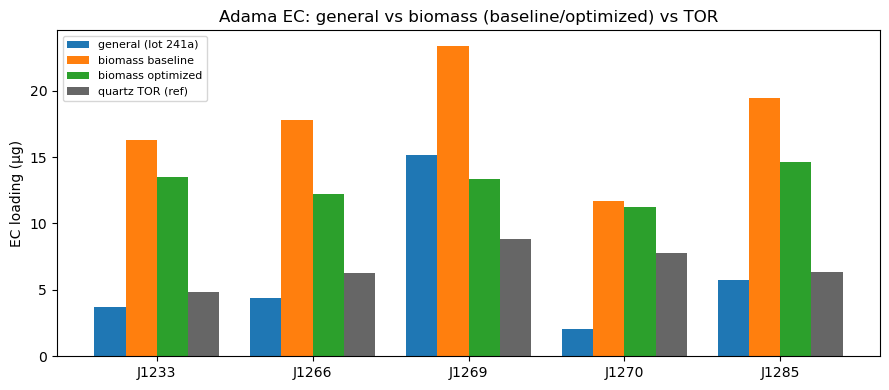

wrote tables/adama_ec_optimized_comparison.csv


In [12]:
x = np.arange(len(cmp)); w = 0.2
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x-1.5*w, cmp.EC_general, w, label="general (lot 241a)")
ax.bar(x-0.5*w, cmp.EC_biomass_baseline, w, label="biomass baseline")
ax.bar(x+0.5*w, cmp.EC_biomass_optimized, w, label="biomass optimized")
ax.bar(x+1.5*w, cmp.ECTR, w, color="k", alpha=0.6, label="quartz TOR (ref)")
ax.set_xticks(x); ax.set_xticklabels(cmp.FilterId); ax.set_ylabel("EC loading (µg)")
ax.set_title("Adama EC: general vs biomass (baseline/optimized) vs TOR"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
cmp.to_csv(HERE / "tables/adama_ec_optimized_comparison.csv", index=False)
print("wrote tables/adama_ec_optimized_comparison.csv")

## Summary

- **Baseline** (no cleaning) = the exported K=31 calibration: includes the odd values.
- **Optimized** = measured-negatives + iterative 3σ residual outliers removed, component count re-picked
  at min CV-RMSEP. The removed filters are listed in Step 4 (by Site/date).
- **Still not reproducible from this export:** Mona's *flagged-questionable / broken-filter* removals —
  the flag column isn't in the model export. To match the tool's manual cleaning exactly we'd need the
  filter status flags (from Mona / the database).
- The Adama comparison shows how the EC predictions move from baseline → optimized, against the
  independent TOR reference.

*This notebook is fully reproducible offline (no Shiny server): it runs on the tool's exact training
data extracted from the model RDS, and sklearn reproduces the tool's PLS to ~1e-10.*